<CENTER><img src="images/logos.png" style="width:50%"></CENTER>

# Introduction to Machine Learning for ATLAS Open Data

## What is Machine Learning?

Machine Learning (ML) is a way of teaching computers to find patterns in data and make predictions without explicitly programming every rule. Think of it like teaching a computer to recognize cats in photos - instead of writing rules like "cats have pointy ears and whiskers," we show the computer thousands of cat and non-cat photos and let it figure out the patterns.

In particle physics, we use ML to distinguish between different types of particle collisions - like telling the difference between a signal we're looking for and background noise.

## Quick Example: Distinguishing Cats from Dogs

Imagine we measure some feautures of animals: `ear_pointiness` on a scale 0-10, `tail_length` (cm) and `meow_frequency` (Hz). We wish to train a our programme to determine whether some unknown animal is a cat or a dog. A type of machine learning model that assigns objects into categories is called a __classifier__.

We use the labels: `0 = dog`, `1 = cat`

#### Step 1: Generate some data

We need some data to train our classifier on. For now, let's create this using normal distributions with different means and standard deviations using the `numpy`'s `random.normal()` function, and plot the data to visualise it.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create some fake animal data
np.random.seed(42)
n_animals = 1500

# Cats tend to have pointier ears, shorter tails, higher meow frequency
cats_ears = np.random.normal(12, 2, n_animals)  # Pointy ears
cats_tails = np.random.normal(2.5, .5, n_animals)  # Short tails
cats_meow = np.random.normal(6, 1, n_animals)  # High frequency meows

# Dogs tend to have less pointy ears, longer tails, lower bark frequency
dogs_ears = np.random.normal(7, 3, n_animals)  # Less pointy ears
dogs_tails = np.random.normal(3.5, .8, n_animals)  # Longer tails
dogs_bark = np.random.normal(3, 1, n_animals)  # Lower frequency barks

# Combine data
features = np.column_stack([ # This function takes a set of 1D arrays and turns them into the columns of a 2D matrix
    np.concatenate([cats_ears, dogs_ears]), # This function joins together our cats_ears and dogs_ears arrays
    np.concatenate([cats_tails, dogs_tails]),
    np.concatenate([cats_meow, dogs_bark])
])

labels = np.concatenate([np.ones(n_animals), np.zeros(n_animals)])  # 1=cat, 0=dog

# We will now 'shuffle' the data so it is in a random order
indices = np.random.permutation(len(features))
features = features[indices] # Passing a list of indices is a fancy way to index several rows in an array one after another!
labels   = labels[indices]

# Histogram the data we generated
cats = features[labels == 1] # If you're curious about how 'boolean masking' technique works, try doing print(labels == 1)
dogs = features[labels == 0]
features_names = ['Ear Pointiness', 'Tail Length (cm)', 'Meow/Bark Frequency (kHz)']
plt.figure(figsize=(15, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    data = [cats[:,i], dogs[:,i]]
    legend = ['Cats', 'Dogs']
    colors = ['purple', 'green']

    plt.hist(data, stacked=True, label=legend, color=colors)
    plt.title(features_names[i])
    plt.xlabel(features_names[i])
    plt.ylabel('Count')
    plt.legend()
plt.tight_layout()
plt.show()


#### Step 2: Train a classifier on our data

Machine Learning is a very well-developed area of computer science. This means we can use pre-existing libraries such as `TensorFlow` and `Scikit-Learn` to train a __classifier__, a machine learning model which is trained to sort items into categories.

The type of classifer we will use is called a __Neural Network__ (this is often shortened to "neural net"). We will explain how a neural network works later - for now, let's just see it in action:

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features) # This 'normalises' the data - MORE ON THIS LATER!
# We do this so that we do not accidentally give more importance to features which naturally have larger values

# Define the model architecture
model = models.Sequential([         # MORE ON THIS LATER!
    layers.Input(shape=(features.shape[1],)),   # Number of "input features"
    layers.Dense(32, activation='sigmoid'),        # "Hidden layer" with 64 neurons
    layers.Dense(1, activation='sigmoid')       # "Output layer": 1 neuron for binary (cat/dog)
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # MORE ON THIS LATER!
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(features_scaled, labels, epochs=100, batch_size=32, verbose=2) # MORE ON THIS LATER!
print("Classifier trained!")

The __Classifer Score Distribution__ is a great way to visualise how well the neural network performs. 

To create this plot, we run the classifier on the array of `features` for each animal - the classifier will predict a probability between `0` and `1` describing how likely it thinks it is that each entry in `features` is a cat. Another name for these probabilities is the __classifier score__.

In this scenario, we can actually check if each entry is a dog or a cat by looking at our `labels` provided. This type of machine learning, where we can go back and check the true values, is called _supervised learning_.

Therefore, we can create a histogram of classifier scores for dogs and cats seperately. If we see that most scores for dogs are close to `0` and most scores for cats are close to `1`, we can conclude that the classifier has done a good job of separating the two animals into distinct categories. 

In [ ]:
y_pred_scores = model.predict(features_scaled).ravel()

# And select corresponding prediction scores:
signal_scores = y_pred_scores[labels == 1] #We are using this classifier to look for cats, so let them be our "signal"
background_scores = y_pred_scores[labels == 0]

# Plot
plt.figure()
plt.hist(signal_scores, bins=50, alpha=0.6, label='Cat', color='purple')
plt.hist(background_scores, bins=50, alpha=0.6, label='Dog', color='green')

plt.xlabel("Classifier Output (score)")
plt.ylabel("Normalized Count")
plt.title("Classifier Score Distribution")
plt.legend()
plt.tight_layout()
plt.yscale('log')
plt.show()

#### Step 3: Classify new animals

Now we have a neural net, we can use it to predict whether an 'unlabeled' (that is, we don't know if it is a cat or a dog) animal is a cat or a dog.

In [ ]:
# Predict on new animal
new_animal = np.array([[6, 36, 4]])  # Somewhat pointy ears, medium tail, mid frequency

# Get prediction probabilities
probability = model.predict(new_animal)  # Returns probability of class 1 (Cat) for binary classification

# Convert probability to class label
# We decide that if there is greater than 50% probability that our new animal is a cat, we will label it as such
prediction = 'cat' if probability > 0.5 else 'Dog' 

# Print results
print(f"New animal prediction: {prediction}")
print(f"Confidence: Cat={probability[0][0]:.2f}, Dog={1 - probability[0][0]:.2f}")

If we had lots of unlabelled data (i.e. a brand new data set we want to classify using our neural net), we could plot a Classifier Score Distribution to see how it looks. 

If we had previously verified that our classifier separates the categories well, and if we see lots of scores clustered around `1` in our new sample, we can reasonably conclude that the new sample does indeed contain cats.

## Our Quick Example Explained - what did we actually do?

### What is a Neuron?

The neural network we used above to classify our dogs and cats is made up of individual **neurons**.

A neuron is a small computing unit. It's like a function that takes some **input features** (numbers), multiplies them by **weights** (which assign a relative importance to each of the input features), adds a **bias**, and passes the result through something called an **activation function**.

Mathematically, we would write:

$\text{output} = f_\text{activation}(w_1 x_1 + w_2 x_2 + ... + w_n x_n + b)$

where:
- $x_1, x_2, ..., x_n$ = input features (e.g., tail length, ear size)
- $w_1, w_2, ..., w_n$ = weights (learned by the model during training)
- $b$ = bias (a number the neuron learns to adjust the output)
- $f_\text{activation}$ = a function that transforms the result (more on this soon!)

Each neuron produces a single number ($y$) as output, based on the inputs it receives. We draw this as:

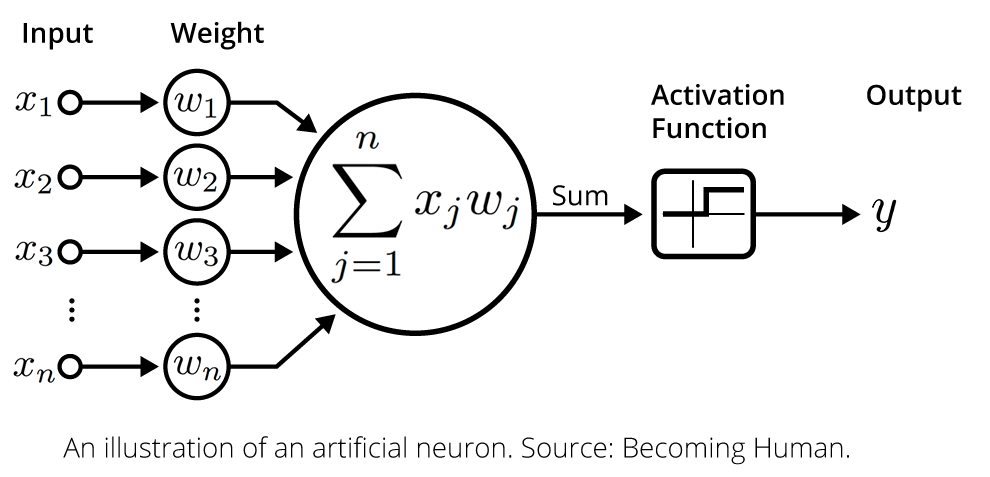


### Building a Neural Network

A **neural network** is just a bunch of these neurons organized into **layers**:

1. **Input Layer**: Receives data (like size, weight, etc.)
2. **Hidden Layers**: Discovers patterns (like "has pointy ears?")
3. **Output Layer**: Makes the final decision (cat or dog?)

with the outputs of one layer feeding into the next layer. A simple diagram of this would be:
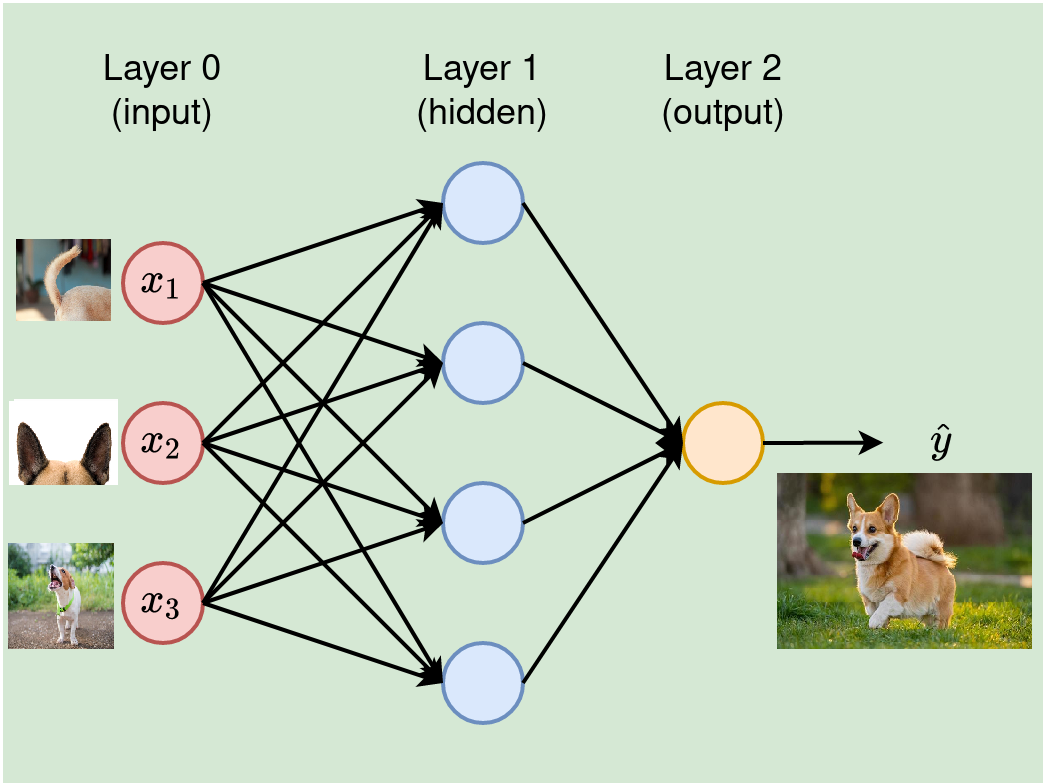

### Activation Functions

Most of the time, we do not want our weighted sum calculated from the inputs to be the direct output of our neuron. Instead, we pass our sums through an __activation function__ to return an output that makes more sense, or is more useful for, the situation to which we are applying our classifier. 

For example, if we would like our neural network to predict probabilities, like in our cats vs dogs example above, we need to make sure the output of our neural network stays between 0 and 1.

<div class="alert alert-warning">

Below are some common activation functions.

- Plot them on the same graph.
- What did we use above?
- What is each one good for?
    
</div>

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

def step(z):
    return np.sign(z)


#Your plotting code here
# ...

<details>
<summary>Plotting Hint: </summary>
    
```python

#Plotting code
z = np.linspace(-5, 5, 200)

plt.figure(figsize=(11,4))
plt.subplot(121)
plt.plot(z, np.sign(z), "r-", linewidth=1, label="Step")
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=2, label="Tanh")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.grid(True)
plt.legend(loc="center right", fontsize=14)
plt.title("Activation functions", fontsize=14)
plt.axis([-5, 5, -1.2, 1.2])
plt.show()

```
</details>

<details>
<summary>Answers: </summary>

<CENTER><img src="images/AFs.png" style="width:100%"></CENTER>

- **ReLU (Rectified Linear Unit)**: $\text{relu}(x) = \text{max}(0, x)$
  - Makes the neuron output 0 if the result is negative, otherwise it keeps it. Good for speeding up training since the output value can be large.
- **Sigmoid**: squashes output to a number between 0 and 1.
  - Great for binary outputs like "cat (0)" or "dog (1)", and probabilities.
- **Tanh** and **Step** are also good for classification, and learn faster since they can have negative outputs.
</details>

### Building the Neural Net in Python

To put all these elements together to create our neural net in Python, all we had to do was:
```python

import tensorflow as tf
from tensorflow.keras import layers, models

# Define the model architecture
model = models.Sequential([
    layers.Input(shape=(features.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
```
Where we define a neural net model with the following parameters:

- `Sequential` means we're stacking layers one after the other.

- `Input(shape=(features.shape[1],))`: The **input layer** expects a number of inputs equal to the number of _features_ (tail length, ear size, etc.) per _sample_ (animal in our dataset).

- `Dense(32, activation='relu')`: A **hidden layer** with 32 neurons using the `ReLU` activation.

- `Dense(1, activation='sigmoid')`: The **output layer** with a single neuron that gives a value between 0 and 1 using the `sigmoid` function — used for binary classification (cat vs dog).


## Training our Neural Network – How Do We Teach It to Classify?

Now that we’ve built our neural network, how does it actually **learn** to tell the difference between a cat and a dog?

### The Training Loop

Training a neural network is a step-by-step process where the model **gradually improves** by learning from data.

Here’s what happens during training:

1. **Input Features Go In**  
   Each training sample (e.g., one animal) is a row of numbers describing it (like tail length, ear shape, etc.).

2. **Make a Prediction (Forward Pass)**  
   The input is passed through the network layer by layer. Each neuron does a weighted sum of inputs and applies an activation function. The final output is a number between 0 and 1 — the **predicted probability** of being a cat.

3. **Compare with True Answer (Loss Calculation)**  
   The prediction is compared to the correct label (1 = cat, 0 = dog). This gives us a **loss** — a measure of how wrong the prediction is.

4. **Learn from Mistakes (Backward Pass)**  
   The network calculates **gradients** — they tell each weight how it contributed to the error. This is called **backpropagation**.

5. **Update the Weights (Optimizer)**  
   The optimizer (like `Adam`) adjusts each weight to reduce the error next time. The goal: make better predictions by learning from mistakes.

6. **Repeat for All Data**  
   This whole process happens across many samples, in **batches**, and for multiple **epochs** (full passes through the dataset).

### Training the Neural Net in Python
To train the model, first, we must __standardise__ the data:

```python
# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features) # This 'normalises' the data
```
This is a _hugely important_ step. We don't want the neural network to get confused by some numbers being different sizes and having different spreads than others, or artificially put more importance on features that just naturally have larger values. For example, just because our `meow_frequency` (Hz) values will be larger than the `ear_pointiness` (0-10) values does not necessarily mean that `meow_frequency` is a more distinguishing feature. Therefore, we scale all the data so that they all have the same mean and standard deviation.

Next we __compile__ the model - this is similar to the way we would first prepare our histograms before filling them in previous notebooks. 

```python
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```
Here, we're preparing the model for training. This means we tell the model a few thiings:
- `optimizer`: What method to use for finding the weights that give the best classification. `Adam` is a popular choice.
- `learning_rate`: How fast the model should change the weights when searching for the best weights.
- `loss`: How the model quantifies how wrong its predictions are when training on the input data
- `metrics`: We want to track the model's accuracy (how often predictions are correct).

Finally, we go ahead and __train__ the model:

```python
# Train the model
model.fit(features_scaled, labels, epochs=100, batch_size=32, verbose=1)
```
We tell the model to fit with the following parameters:
- `features_scaled`: The normalised input data. Each row is one animal.
- `labels`: An array of 0s and 1s — 0 = dog, 1 = cat. This tells the optimizer what the 'correct' answers are for the training data
- `batch_size`: How many rows of input processed before updating weights when learning.
- `epochs`: How many times the model will go through the entire dataset whilst learning.

## Training and Validation

When using Machine Learning, we need to be really careful **not to let the model just memorize the training data**. Our goal is to build a model that can **generalize** — meaning, it performs well not just on the data it has seen, but also on new, unseen examples.

To do this, we split our data into two sets:

- **Training Data**: This is the data the model actually learns from. During training, the model adjusts its weights to reduce its error on this data.
- **Validation Data**: This is a separate chunk of data that the model **does not see** during training. It acts like a mini "exam" to check how well the model is doing on unseen data.

### Why Do We Split the Data?

Just like you don’t study for a test by memorizing the answer key, a model shouldn't be evaluated on the same data it learns from. By checking performance on validation data, we can detect problems such as:

- **Overfitting**: The model performs well on training data but has a lower accuracy on the validation data. It has memorized the training examples instead of learning general rules.
- **Underfitting**: The model performs poorly on both training and validation data. It hasn’t learned the patterns yet.

To solve overfitting, we have a few options:
- Change the shape of the neural net e.g. the number layers, the number of neurons in each layer
- Reduce the number of epochs, or lower the learning rate

### How to Use Validation Data in Code

`TensorFlow` and  `Scikit-learn` make it easy to include validation data when training the model. Let's start by splitting our original dataset into 40 animals for training and 10 for validation. Then we pass only the training data into the `fit()` function for fitting. The validation data are passed separately using the `validation_data` parameter.

In [ ]:
from sklearn.model_selection import train_test_split #This function makes splitting up our dataset easy

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split data - test_size parameter sets what proportion of the data should be reserved for testing
features_train, features_validation, labels_train, labels_validation = train_test_split(
    features_scaled, labels, test_size=0.3, random_state=42, stratify=labels
)

# Define a fresh model (which hasn't been trained yet)
model = models.Sequential([
    layers.Input(shape=(features.shape[1],)),
    layers.Dense(32, activation='sigmoid'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train and specify validation data
training_history = model.fit(
    features_train, labels_train,
    validation_data=(features_validation, labels_validation),
    epochs=100,
    batch_size=32,
    verbose=1
)

Now let's plot the classifier's accuracy on the training and validation data respectively:

In [ ]:
plt.plot(training_history.history['accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel(r'Epoch (becoming more trained $\rightarrow$)')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

<div class="alert alert-warning">

- What does this graph tell us? 

- Are we over training (remind yourself of the definition above)?
    
</div>

Rerun the cell a few times to see whether your conclusions change.

<details>
<summary>Answers: </summary>

The graph tells us that as the training advances (i.e. as we progress through the epochs) the accuracy of classifying the animals on both the training and validation sets increases - yay! 

However, in some other cases the model will train quickly, and the validation accuracy will be less than the accuracy on the training set. Such a scenario would indicate overtraining.

</details>

### A few last things!

#### The loss

There are many evaluation metrics to tell us how well our for our neural net it performing.

One example is the **accuracy** (how often the model's predictions are correct), which we have plotted above. Another example, the **loss** (how the model quantifies how wrong its predictions are, calculated using a _loss function_), can also help assess whether we have overtrained or undertrained.

In [ ]:
loss = training_history.history['loss']
val_loss = training_history.history['val_loss']

plt.plot(loss, label='Training loss')
plt.plot(val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel(r'Epoch (becoming more trained $\rightarrow$)')
plt.ylabel('Loss')
plt.legend()
plt.show()

<div class="alert alert-warning">

How can this graph tell us when we should stop training?
</div>


<details>
<summary>Answer: </summary>

We should stop training after the loss has sufficiently converged to its minimum value but before the classifier becomes overtrained.

</details>

#### The Classifier Score Distriubtion

We have aleady encountered this above, but this is another great way to visualise how well the neural net performs. 

We run classifier on all the data, and then plot the score assigned to each data point, separately for each category. If we see good separation between categories, we can be confident when assigning a category to an unlabelled data point based on the score assigned by the neural net to it.

In [ ]:
y_pred_scores = model.predict(features_scaled).ravel()  # sigmoid output: values between 0 and 1

# And select corresponding prediction scores:
signal_scores = y_pred_scores[labels == 1]
background_scores = y_pred_scores[labels == 0]

# Plot
plt.figure()
plt.hist(signal_scores, bins=50, alpha=0.6, label='Cat', color='purple')
plt.hist(background_scores, bins=50, alpha=0.6, label='Dog', color='green')

plt.xlabel("Classifier Output (score)")
plt.ylabel("Normalized Count")
plt.title("Classifier Score Distribution")
plt.legend()
plt.tight_layout()
plt.yscale('log')
plt.show()

#### And finally, Feature Importances...

We might also want to ask how important each feature, e.g. ear pointiness, was in order to classify the animals. 

To do this we can run the classifier on our data, but after shuffling the `ear_pointiness` for the animals. This means the `ear_pointiness` of each animal is now essentially random and the model will no longer be able to find patterns in and classify based on ear pointiness, leading to a drop in accuracy. 

This drop in accuracy quantifies the importance of the feature in classification - repeating for each feature lets us find the importance of each.

This method of quantifying feature importance is called **Permutation Feature Importance**.


In [ ]:
def permutation_importance(model, X_val, y_val, metric='accuracy'):
    baseline = model.evaluate(X_val, y_val, verbose=0)[1]  # e.g., accuracy
    importances = []
    
    for i in range(X_val.shape[1]):
        X_val_permuted = X_val.copy()
        shuffled = X_val_permuted[:, i].copy()
        np.random.shuffle(shuffled)
        X_val_permuted[:, i] = shuffled

        permuted_score = model.evaluate(X_val_permuted, y_val, verbose=0)[1]
        importance = baseline - permuted_score
        importances.append(importance)
    
    return np.array(importances)


importances = permutation_importance(model, features, labels)

plt.bar(features_names, importances, color='skyblue')
plt.ylabel('Importance (accuracy drop)')
plt.title('Permutation Feature Importance')
plt.show()

<div class="alert alert-success">
Congratulations - you know understand the fundamentals of machine learning and neural networks!
    
Head to the next book, "$\text{} \to 4l$ with a Neural Net" to try a hands-on example with ATLAS data.
    
</div>